In [62]:
import torch # install GPU-compatible
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, get_linear_schedule_with_warmup, AutoConfig
from datasets import Dataset
import evaluate
from tqdm import tqdm
from torch.nn import functional as F
import numpy as np
import pandas as pd
from torch.optim import AdamW
#from sysml_utils import SysMLASTManager
from transformers import AutoModelForSeq2SeqLM, Trainer, TrainingArguments
from transformers import default_data_collator

model_name = "Salesforce/codet5-small"
cache_dir = "./models" 

import os
os.makedirs("models/trained", exist_ok=True)

In [63]:
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=cache_dir)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name, cache_dir=cache_dir)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def count_tokens(text: str) -> int:
    tokens = tokenizer.encode(text, add_special_tokens=False)
    return len(tokens)

In [64]:
import matplotlib.pyplot as plt

def plot_token_lengths(dataset, column_name):

    # Handle both Hugging Face Dataset and pandas DataFrame
    if hasattr(dataset, "to_pandas"):
        texts = dataset[column_name]  # works for Hugging Face Datasets
    else:
        texts = dataset[column_name]  # works for pandas DataFrame

    # Convert all entries to string (safe)
    texts = [str(t) for t in texts]

    # Tokenize and count
    token_counts = [len(tokenizer.encode(t, add_special_tokens=False)) for t in texts]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(token_counts)), token_counts)
    plt.xlabel("Example index")
    plt.ylabel("Token count")
    plt.title(f"Token counts per example")
    plt.grid(True)
    plt.show()

    return token_counts


In [66]:
basic_df = pd.read_json("dataset/synthetic_dataset_basic_expanded_final.jsonl", lines=True)
domain_df = pd.read_json("dataset/synthetic_dataset_domain_aware_full2.jsonl", lines=True) 

merged_df = pd.concat([basic_df, domain_df], ignore_index=True)
dataset = Dataset.from_pandas(merged_df)

Token indices sequence length is longer than the specified maximum sequence length for this model (937 > 512). Running this sequence through the model will result in indexing errors


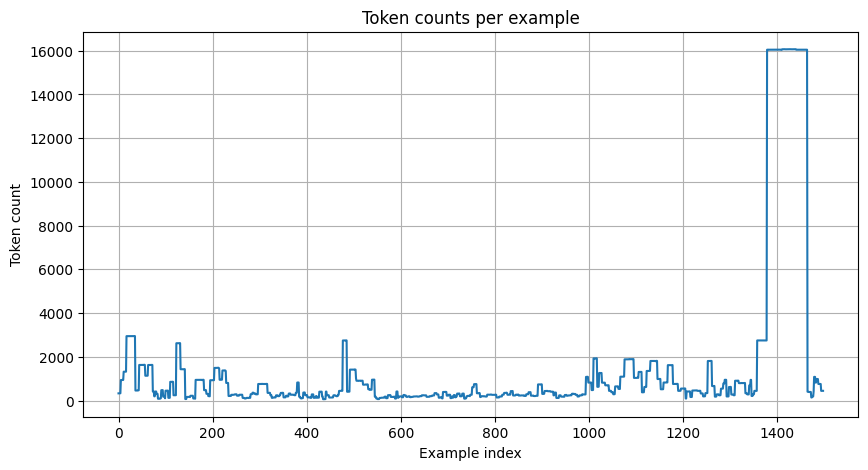

In [67]:
token_counts = plot_token_lengths(dataset, "bad_code")

In [ ]:
example = dataset[7]

def count_lines(s):
    print(len(s.splitlines()))

def count_tokens(text: str) -> int:
    tokens = tokenizer.encode(text, add_special_tokens=False)
    print(len(tokens))

def get_line(text, n):
    print(text.splitlines()[n - 1])

In [ ]:
error = example["error_message"]
formatted_error = error.replace("ERROR:", "\nERROR:")
code = example["bad_code"]
count_tokens(code)
count_tokens(error)
get_line(code, 81)

In [ ]:
print(formatted_error)
print(code)

In [ ]:
text = example["bad_code"]
print(count_tokens(text))  
print(text)

In [ ]:
def count_lines(s):
    print(len(s.splitlines()))

count_lines(example["bad_code"])

In [ ]:
bad_code = '''part system {
            part eng : Engine;      // mechanical
            part bulb : Light;      // electrical
            part trans : Gearbox;   // mechanical
            
        }'''

good_code = '''part system {
            part eng : Engine;      // mechanical
            part bulb : Light;      // electrical
            part trans : Gearbox;   // mechanical
            
            connect eng.p to trans.p;
        }'''
from typing import List, Dict
def count_occurrences(haystack: List[str], needle: List[str]) -> int:
    if not needle:
        return 0
    count = 0
    n = len(needle)
    for i in range(len(haystack) - n + 1):
        if haystack[i:i+n] == needle:
            count += 1
    return count

In [ ]:
from typing import List, Dict, Optional
import difflib


def compare_code_lines(bad_lines: list[str], good_lines: list[str], merge_threshold: int) -> Optional[list[tuple]]:
    """Compare two lists of code lines and return merged diff hunks."""
    matcher = difflib.SequenceMatcher(a=bad_lines, b=good_lines)
    raw_hunks = [
        (i1, i2, j1, j2)
        for tag, i1, i2, j1, j2 in matcher.get_opcodes()
        if tag != "equal"
    ]

    if not raw_hunks:
        return None

    merged = []
    current = list(raw_hunks[0])

    for i1, i2, j1, j2 in raw_hunks[1:]:
        if i1 - current[1] <= merge_threshold:
            current[1] = i2  # extend bad-region end
            current[3] = j2  # extend good-region end
        else:
            merged.append(tuple(current))
            current = [i1, i2, j1, j2]

    merged.append(tuple(current))
    return merged


def is_all_empty(strings: list[str]) -> bool:
    """Check if all strings are empty or whitespace-only."""
    return all(not s.strip() for s in strings)


def occurs_exactly_once(haystack: list[str], needle: list[str]) -> bool:
    """Check if needle appears exactly once in haystack."""
    if not needle:
        return False
    
    needle_len = len(needle)
    haystack_len = len(haystack)
    count = 0
    
    for i in range(haystack_len - needle_len + 1):
        if haystack[i : i + needle_len] == needle:
            count += 1
            if count > 1:  # Early exit optimization
                return False
    
    return count == 1


def generate_contextual_patches(
        bad_code: str,
        good_code: str,
        merge_threshold: int = 3, 
        max_context: int = 50
        ) -> List[Dict[str, str]]:

    """Generate contextual patches to transform bad_code into good_code."""
    bad_lines = bad_code.splitlines()
    good_lines = good_code.splitlines()

    merged = compare_code_lines(bad_lines, good_lines, merge_threshold)

    if not merged:
        return []

    patches = []

    for i1, i2, j1, j2 in merged:
        before_block = bad_lines[i1:i2]
        after_block = good_lines[j1:j2]

        # If before_block is non-empty and unique, no context needed
        if not is_all_empty(before_block) and occurs_exactly_once(
            bad_lines, before_block
        ):
            patches.append({
                "context": "",
                "before": "\n".join(before_block),
                "after": "\n".join(after_block),
            })
        else:
            # Need to find unique context
            context_size = 0
            context_before = []

            while context_size < max_context:
                # Expand context backwards until we hit a non-empty line
                while context_size < i1:
                    context_size += 1
                    context_before = bad_lines[i1 - context_size : i1]
                    if not is_all_empty(context_before):
                        break
                
                # Check if context + before_block is unique
                candidate = context_before + before_block
                if occurs_exactly_once(bad_lines, candidate) or context_size >= i1:
                    break

                # Need more context - increment and continue
                if context_size < i1:
                    context_size += 1
                    context_before = bad_lines[i1 - context_size : i1]
                else:
                    break

            patches.append({
                "context": "\n".join(context_before),
                "before": "\n".join(before_block),
                "after": "\n".join(after_block),
            })

    return patches

In [ ]:
example = dataset[7]
bad_code = example["bad_code"]
good_code = example["good_code"]
error = example["error_message"]
patches = generate_contextual_patches(bad_code, good_code)
print(patches)


In [ ]:
ans = generate_contextual_patches(bad_code, good_code)
print(ans)

In [ ]:
from typing import List, Dict
import difflib


def apply_patches(bad_code: str,
                  patches: List[Dict[str, str]]) -> str:
    """
    Apply context-aware BEFORE/AFTER patches to SysML (or any) code.
    Patches have keys:
        "context": str  (may be empty)
        "before": str
        "after": str
    The function returns updated code after all patches.
    """

    lines = bad_code.splitlines()

    for patch in patches:
        context = patch["context"].splitlines() if patch["context"] else []
        before  = patch["before"].splitlines()
        after   = patch["after"].splitlines()

        target_block = context + before
        replacement_block = context + after

        # Attempt exact match first
        idx = find_exact_sublist(lines, target_block)

        if idx == -1:
            raise RuntimeError("Could not locate patch in code.")

        # Apply replacement
        end = idx + len(target_block)
        lines = lines[:idx] + replacement_block + lines[end:]

    return "\n".join(lines)



def find_exact_sublist(haystack: List[str], needle: List[str]) -> int:
    """Find exact consecutive match. Returns starting index or -1."""
    if not needle:
        return -1
    n = len(needle)
    for i in range(len(haystack) - n + 1):
        if haystack[i:i+n] == needle:
            return i
    return -1

In [ ]:
def codes_match_strict(corrected: str, good: str) -> bool:
    return corrected == good

def codes_match_normalized(corrected: str, expected: str) -> bool:
    def normalize(code: str):
        # Remove trailing spaces, normalize newlines, collapse indent variations
        return "\n".join(line.rstrip() for line in code.splitlines()).strip()

    return normalize(corrected) == normalize(expected)


In [ ]:
passed = []
failed = []
err_failed = []

for idx, example in enumerate(dataset):
    try: 
        bad_code = example["bad_code"]
        good_code = example["good_code"]
    
        if codes_match_strict(bad_code, good_code):
            passed.append(idx)
        else:
            failed.append(idx)
    except Exception as e:
        err_failed.append((idx))

print(f"Passed: {len(passed)}, Failed: {len(failed)}, Errors: {len(err_failed)}")

In [ ]:
passed = []
failed = []
err_failed = []

for idx, example in enumerate(dataset):
    try: 
        bad_code = example["bad_code"]
        good_code = example["good_code"]
        patches = generate_contextual_patches(bad_code, good_code)
        corrected_code = apply_patches(bad_code, patches)
        if codes_match_normalized(corrected_code, good_code):
            passed.append(idx)
        else:
            failed.append(idx)
    except Exception as e:
        err_failed.append((idx))

print(f"Passed: {len(passed)}, Failed: {len(failed)}, Errors: {len(err_failed)}")
print("Failed indices:", failed)

In [ ]:
passed = []
failed = []
err_failed = []

for idx, example in enumerate(dataset):
    try: 
        bad_code = example["bad_code"]
        good_code = example["good_code"]
        patches = generate_contextual_patches(bad_code, good_code)
        
        if patches:
            passed.append(idx)
        else:
            failed.append(idx)
    except Exception as e:
        err_failed.append((idx))

print(f"Passed: {len(passed)}, Failed: {len(failed)}, Errors: {len(err_failed)}")
print("Failed indices:", failed)

In [ ]:
import difflib

def print_diff(a: str, b: str, title_a="Corrected", title_b="Expected"):
    diff = difflib.unified_diff(
        a.splitlines(),
        b.splitlines(),
        fromfile=title_a,
        tofile=title_b,
        lineterm=""
    )
    print("\n".join(diff))


passed = []
failed = []
err_failed = []

for idx, example in enumerate(dataset):
    try:
        bad_code = example["bad_code"]
        good_code = example["good_code"]

        patches = generate_contextual_patches(bad_code, good_code)
        corrected_code = apply_patches(bad_code, patches)

        if codes_match_normalized(corrected_code, good_code):
            passed.append(idx)
        else:
            failed.append(idx)

            print("=" * 60)
            print(f"FAILED EXAMPLE {idx}")

            # Show the patches generated
            print("\nPATCHES:")
            for p in patches:
                print("\n--- PATCH ---")
                print("CONTEXT:\n", p["context"])
                print("BEFORE:\n", p["before"])
                print("AFTER:\n", p["after"])

            # Show diff between corrected and expected code
            print("\nDIFF (Corrected vs Expected):")
            print_diff(corrected_code, good_code)

            # Optional: show diff between bad code and good code
            print("\nDIFF (Bad vs Expected):")
            print_diff(bad_code, good_code)

            print("=" * 60)

    except Exception as e:
        err_failed.append(idx)
        print("=" * 60)
        print(f"ERROR in EXAMPLE {idx}: {e}")
        print("=" * 60)

print(f"Passed: {len(passed)}, Failed: {len(failed)}, Errors: {len(err_failed)}")


In [ ]:
def preprocess_data(batch, keep_original=True):
    input_texts = [
        f"Fix the following SysML code.\n### Faulty Code:\n{wc}\n### Error:\n{err}"
        for wc, err in zip(batch["bad_code"], batch["error_message"])
    ]
    target_texts = [
        f"Here is the correct code:\n{code}"
        for code in batch["good_code"]
    ]

    if keep_original:
        batch["input_text"] = input_texts
        batch["target_text"] = target_texts
        return batch
    else:
        return {"input_text": input_texts, "target_text": target_texts}


def group_split(dataset, test_size=0.1, val_size=0.1, seed=42):
    base_ids = list(set(dataset["source_id"]))
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(base_ids)

    n = len(shuffled)
    n_test = int(test_size * n)
    n_val = int(val_size * n)

    test_groups = set(shuffled[:n_test])
    val_groups  = set(shuffled[n_test:n_test+n_val])

    def label_row(example):
        if example["source_id"] in test_groups:
            return {"split": "test"}
        elif example["source_id"] in val_groups:
            return {"split": "val"}
        else:
            return {"split": "train"}

    dataset = dataset.map(label_row)

    train_ds = dataset.filter(lambda x: x["split"] == "train").remove_columns("split")
    val_ds   = dataset.filter(lambda x: x["split"] == "val").remove_columns("split")
    test_ds  = dataset.filter(lambda x: x["split"] == "test").remove_columns("split")

    return train_ds, val_ds, test_ds

dataset = dataset.map(preprocess_data, batched=True)
train_ds, val_ds, test_ds = group_split(dataset)
print(f"Datatset Sizes: \nTraining: {len(train_ds)}, Validation: {len(val_ds)}, Test: {len(test_ds)}")

In [ ]:
def tokenize_function(batch, max_length=256):

    model_inputs = tokenizer(
        text=batch["input_text"],
        text_target=batch["target_text"],
        max_length=max_length,
        padding="max_length",
        truncation=True,
    )

    return model_inputs

train_tokenized = train_ds.map(tokenize_function, batched=True, remove_columns=train_ds.column_names)
val_tokenized = val_ds.map(tokenize_function, batched=True, remove_columns=val_ds.column_names)
test_tokenized = test_ds.map(tokenize_function, batched=True, remove_columns=test_ds.column_names)

train_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [ ]:
def tokenize_function(batch, max_length=256):

    model_inputs = tokenizer(
        text=batch["input_text"],
        text_target=batch["target_text"],
    )

    return model_inputs

dataset_tok = dataset.map(tokenize_function, batched=True, remove_columns=train_ds.column_names)

In [ ]:
import matplotlib.pyplot as plt

def plot_seq_lengths_over_examples(dataset, num_samples=None):
    """Plot sequence lengths vs example index (dataset order)."""
    if num_samples:
        dataset = dataset.select(range(min(num_samples, len(dataset)))) if hasattr(dataset, "select") else dataset[:num_samples]

    input_lengths = [len(example["input_ids"]) for example in dataset]
    label_lengths = [len(example["labels"]) for example in dataset]

    plt.figure(figsize=(10, 5))
    plt.plot(input_lengths, label="Input length", alpha=0.8)
    plt.plot(label_lengths, label="Label length", alpha=0.8)
    plt.xlabel("Example index (dataset order)")
    plt.ylabel("Sequence length (tokens)")
    plt.title("Sequence Lengths Across Dataset (Ordered)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Inputs: mean={sum(input_lengths)/len(input_lengths):.1f}, max={max(input_lengths)}, min={min(input_lengths)}")
    print(f"Labels: mean={sum(label_lengths)/len(label_lengths):.1f}, max={max(label_lengths)}, min={min(label_lengths)}")

# Example usage:
plot_seq_lengths_over_examples(dataset_tok)



In [ ]:
def compute_accuracy(outputs, labels):
    preds = outputs.logits.argmax(-1)
    mask = labels != -100

    correct = (preds == labels) & mask
    accuracy = correct.sum().item() / mask.sum().item()
    return accuracy

In [ ]:
train_loader = DataLoader(train_tokenized, batch_size=4, shuffle=True, collate_fn=default_data_collator)
val_loader   = DataLoader(val_tokenized, batch_size=4, collate_fn=default_data_collator)

num_epochs = 10
optimizer = AdamW(model.parameters(), lr=5e-5)
num_training_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

In [ ]:
train_losses = []
val_losses = []
best_val_loss = float('inf') 
patience = 2
patience_counter = 0

for epoch in range(num_epochs):

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1} [Training]")
    model.train()
    train_loss = 0.0
    
    for batch in train_loop:
        for k,v in batch.items():
            batch[k] = v.to(device)
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1} [Validation]")
    model.eval()
    val_loss = 0.0
    total_acc = 0.0
    
    with torch.no_grad():
        for batch in val_loop:
            for k,v in batch.items():
                batch[k] = v.to(device)
            outputs = model(**batch)
            val_loss += outputs.loss.item()
            labels = batch["labels"]
            acc = compute_accuracy(outputs, labels)
            total_acc += acc

    avg_val_loss = val_loss / len(val_loader)
    avg_acc = total_acc / len(val_loader)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss: 
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "models/trained/best_model.pt")
        print(f"Train loss: {avg_train_loss:.4f}, Validation loss: {avg_val_loss:.4f}, Best: {best_val_loss:.4f}, Accuracy: {avg_acc:.4f}")
    else:
        patience_counter += 1
        print(f"Train loss: {avg_train_loss:.4f}, Validation loss: {avg_val_loss:.4f}, Best: {best_val_loss:.4f}, Accuracy: {avg_acc:.4f}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

print(f"Best model saved (val loss = {best_val_loss:.4f})")

In [ ]:
model.load_state_dict(torch.load("models/trained/best_model.pt"))
model.to(device)
model.eval()
import torch, gc
gc.collect()
torch.cuda.empty_cache()
test_loader = DataLoader(test_tokenized, batch_size=1, collate_fn=default_data_collator)

In [ ]:
generated_texts = []
reference_texts = []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Generating"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # Generate output
        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            num_beams=4,          # or 1 for greedy
            max_new_tokens=256,     # generate up to 256 new tokens
            early_stopping=False,   # ignore early EOS
        )

        # Decode both
        preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        labels = tokenizer.batch_decode(batch["labels"], skip_special_tokens=True)

        generated_texts.extend(preds)
        reference_texts.extend(labels)


In [ ]:
# compute BLEU
bleu = evaluate.load("sacrebleu")  # optional
results = bleu.compute(predictions=generated_texts,
                       references=[[r] for r in reference_texts])

print(f"BLEU score: {results['score']:.2f}")
exact_matches = sum(p.strip() == r.strip() for p, r in zip(generated_texts, reference_texts))
exact_match_acc = exact_matches / len(reference_texts)
print(f"Exact-match accuracy: {exact_match_acc:.3f}")

In [ ]:
print(tokenizer.eos_token, tokenizer.eos_token_id)
print(model.config.eos_token_id)


In [ ]:
for i in range(5):
    print(f"Reference: {reference_texts[i]}")
    print(f"Generated: {generated_texts[i]}")
    print("---")


In [ ]:
from transformers.trainer_utils import EvalPrediction

def compute_metrics(eval_pred: EvalPrediction):
    preds = eval_pred.predictions
    labels = eval_pred.label_ids
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    print("Trynna compute metrics")

    pred_texts = tokenizer.batch_decode(preds, skip_special_tokens=True)
    label_texts = tokenizer.batch_decode(labels, skip_special_tokens=True)

    acc = np.mean([p.strip() == l.strip() for p, l in zip(pred_texts, label_texts)])
    return {"accuracy": acc}

In [ ]:
# old code, uses trainer
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback

training_args = Seq2SeqTrainingArguments(
    output_dir="./checkpoints",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    fp16=True,  # use mixed precision, lowers memeory usage

    report_to="none",
    do_eval=True,
    predict_with_generate=False,
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]

)
#eval_accumulation_steps=1,     # prevents OOM
trainer.train()

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()


from transformers import AutoModelForSeq2SeqLM

model_path = "./checkpoints"
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)
model.eval()
model.to("cuda")


In [ ]:
test_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Then:
test_results = trainer.predict(test_tokenized)
print(test_results.metrics)

In [ ]:
import evaluate, numpy as np
metric = evaluate.load("accuracy")

from tqdm import tqdm

def evaluate_model(model, tokenizer, dataset, max_length=128):
    preds, refs = [], []
    for batch in tqdm(dataset, desc="Evaluating"):
        inputs = tokenizer(
            batch["input_text"],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        ).to("cuda")

        with torch.no_grad():
            outputs = model.generate(**inputs, max_length=max_length)

        pred_str = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        ref_str = batch["target_text"]

        preds.extend(pred_str)
        refs.extend(ref_str)

    acc = np.mean([p.strip() == r.strip() for p, r in zip(preds, refs)])
    return acc

# Run
test_acc = evaluate_model(model, tokenizer, test_dataset)
print(f"Final test accuracy: {test_acc:.3f}")
